# Supervised Learning

## Regression

### Dataset: Karyawan Perusahaan XYZ (`dataset_karyawan_missing.csv`)

Dataset ini berisi data historis karyawan Perusahaan XYZ. Target regresi adalah kolom **`Gaji`** yang merepresentasikan gaji bulanan karyawan (dalam Rupiah).

Fitur yang digunakan:
- **`Usia`** : Usia karyawan (tahun)
- **`Lama_Kerja`** : Lama bekerja di perusahaan (tahun)
- **`Status_Karyawan`** : Status karyawan (Tetap / Kontrak)
- **`Departemen`** : Departemen tempat bekerja (HRD / QC / Produksi / Logistik)

---

## 1. Preparation

Untuk persiapan, kita akan memanggil seluruh library yang akan kita pakai pada project kali ini

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
%matplotlib inline

In [2]:
train = pd.read_csv('dataset_karyawan_missing.csv')
train.head()

,ID,Nama,Departemen,Gaji,Usia,Lama_Kerja,Status_Karyawan
0,1,Citra,NaN,5744870.0,53,9,Kontrak
1,2,Eka,HRD,5862014.0,39,9,Tetap
2,3,Citra,HRD,4894992.0,55,16,Tetap
3,4,Budi,QC,4606286.0,51,2,Kontrak
4,5,Dewi,HRD,4199766.0,44,7,Kontrak


---
## 2. Exploratory Data Analysis

In [3]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   ID               200 non-null    int64  
 1   Nama             200 non-null    object 
 2   Departemen       190 non-null    object 
 3   Gaji             190 non-null    float64
 4   Usia             200 non-null    int64  
 5   Lama_Kerja       200 non-null    int64  
 6   Status_Karyawan  200 non-null    object 
dtypes: float64(1), int64(3), object(3)
memory usage: 11.1+ KB


In [4]:
d = train.describe()
d

,ID,Gaji,Usia,Lama_Kerja
count,200.000000,1.900000e+02,200.000000,200.000000
mean,100.500000,5.053853e+06,41.545000,14.455000
std,57.879185,7.778678e+05,10.367517,8.277716
min,1.000000,2.786682e+06,22.000000,0.000000
25%,50.750000,4.594828e+06,34.000000,7.750000
50%,100.500000,5.040414e+06,42.000000,15.000000
75%,150.250000,5.602506e+06,49.250000,21.000000
max,200.000000,6.941904e+06,59.000000,29.000000


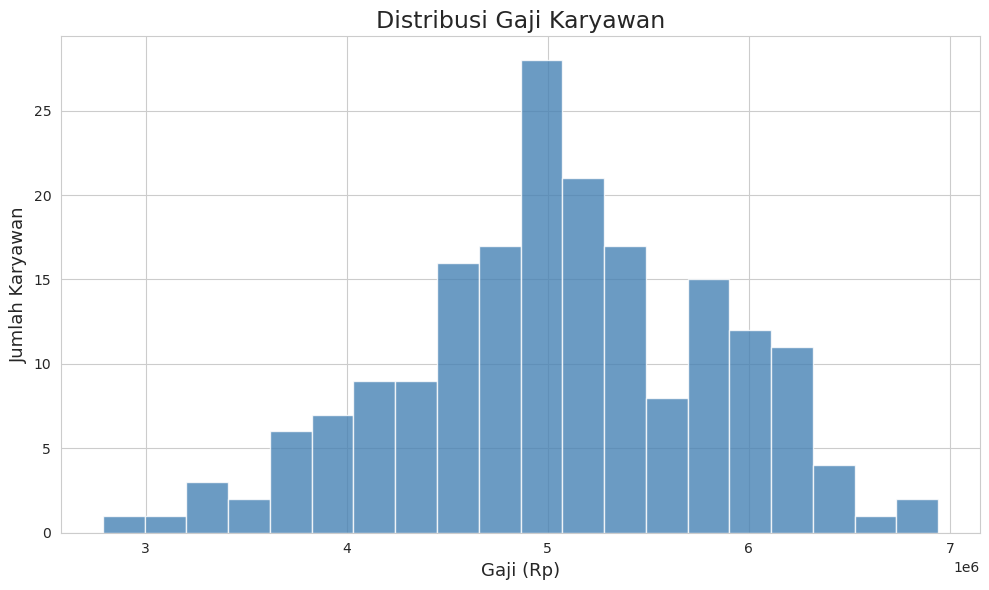

In [5]:
# Distribusi Gaji Karyawan
sns.set_style('whitegrid')
plt.figure(figsize=(10, 6))
train['Gaji'].dropna().hist(bins=20, color='steelblue', alpha=0.8, edgecolor='white')
plt.xlabel("Gaji (Rp)", fontsize=13)
plt.ylabel("Jumlah Karyawan", fontsize=13)
plt.title("Distribusi Gaji Karyawan", fontsize=17)
plt.tight_layout()
plt.show()

/tmp/ipykernel_72886/3408179191.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Status_Karyawan', y='Gaji', data=train, palette='RdBu_r')


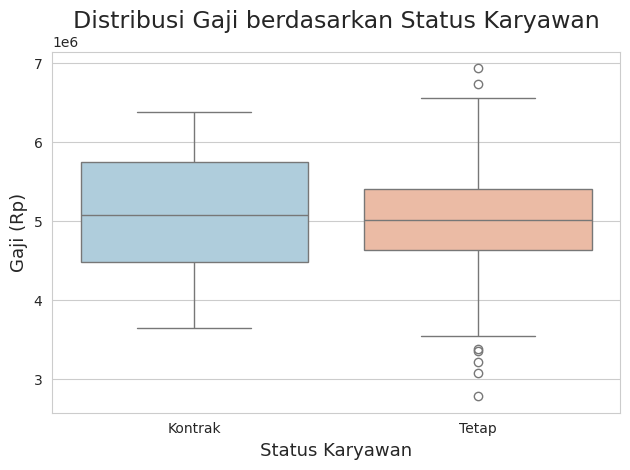

In [6]:
# Gaji berdasarkan Status Karyawan
sns.set_style('whitegrid')
sns.boxplot(x='Status_Karyawan', y='Gaji', data=train, palette='RdBu_r')
plt.title("Distribusi Gaji berdasarkan Status Karyawan", fontsize=17)
plt.xlabel("Status Karyawan", fontsize=13)
plt.ylabel("Gaji (Rp)", fontsize=13)
plt.tight_layout()
plt.show()

/tmp/ipykernel_72886/38644231.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Departemen', y='Gaji', data=train, palette='rainbow')


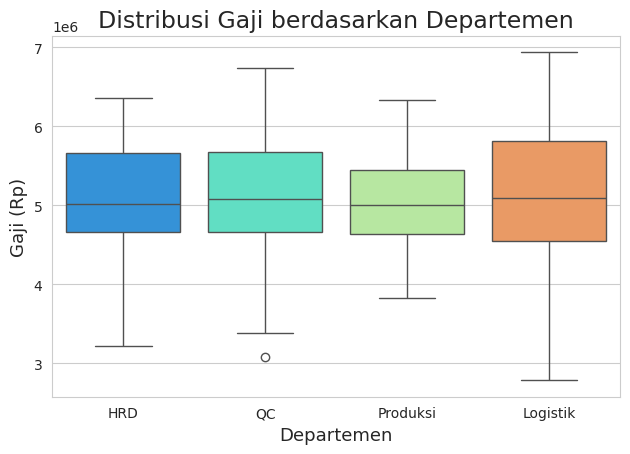

In [7]:
# Gaji berdasarkan Departemen
sns.set_style('whitegrid')
sns.boxplot(x='Departemen', y='Gaji', data=train, palette='rainbow')
plt.title("Distribusi Gaji berdasarkan Departemen", fontsize=17)
plt.xlabel("Departemen", fontsize=13)
plt.ylabel("Gaji (Rp)", fontsize=13)
plt.tight_layout()
plt.show()

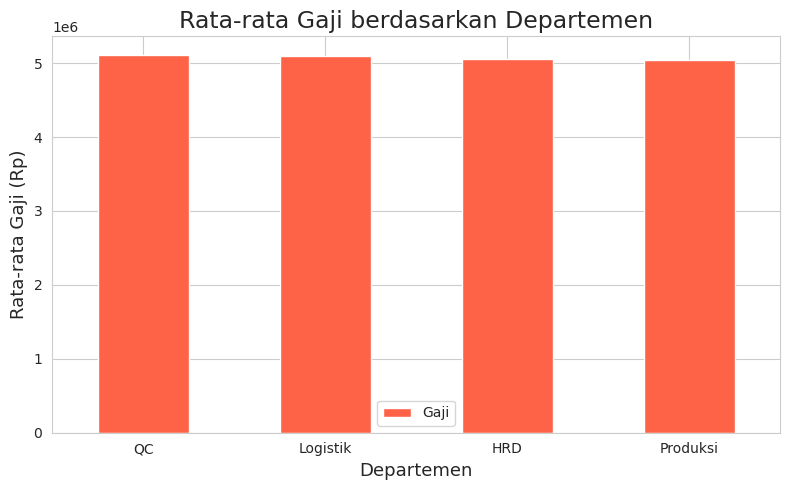

In [8]:
# Rata-rata Gaji per Departemen
f_dept_gaji = train.groupby('Departemen')['Gaji'].mean().sort_values(ascending=False)
f_dept_gaji = pd.DataFrame(f_dept_gaji)
f_dept_gaji.plot.bar(y='Gaji', color='tomato', figsize=(8, 5))
plt.title("Rata-rata Gaji berdasarkan Departemen", fontsize=17)
plt.ylabel("Rata-rata Gaji (Rp)", fontsize=13)
plt.xlabel("Departemen", fontsize=13)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

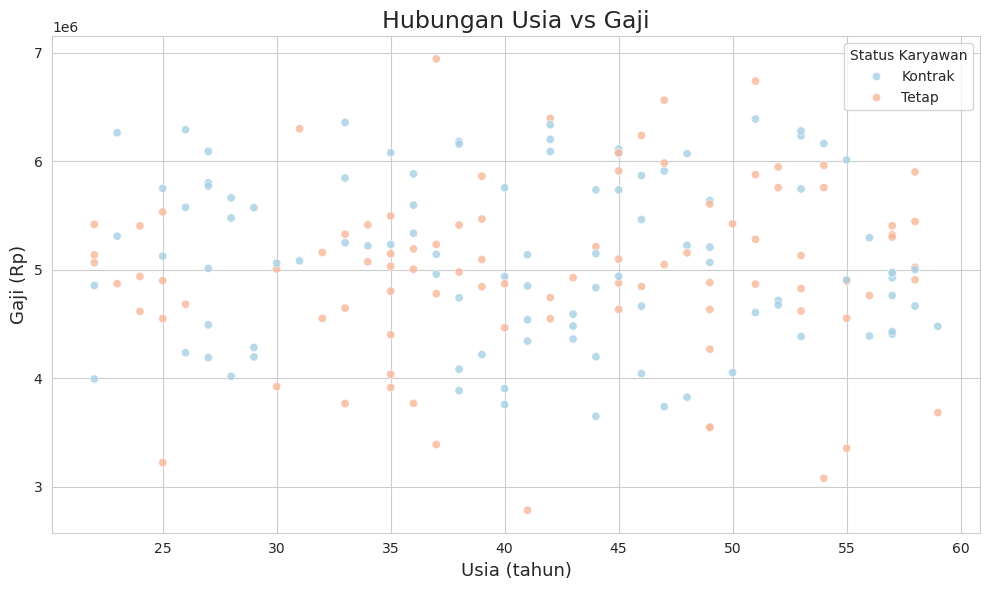

In [9]:
# Scatter Plot: Usia vs Gaji
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Usia', y='Gaji', hue='Status_Karyawan', data=train, palette='RdBu_r', alpha=0.8)
plt.title("Hubungan Usia vs Gaji", fontsize=17)
plt.xlabel("Usia (tahun)", fontsize=13)
plt.ylabel("Gaji (Rp)", fontsize=13)
plt.legend(title='Status Karyawan')
plt.tight_layout()
plt.show()

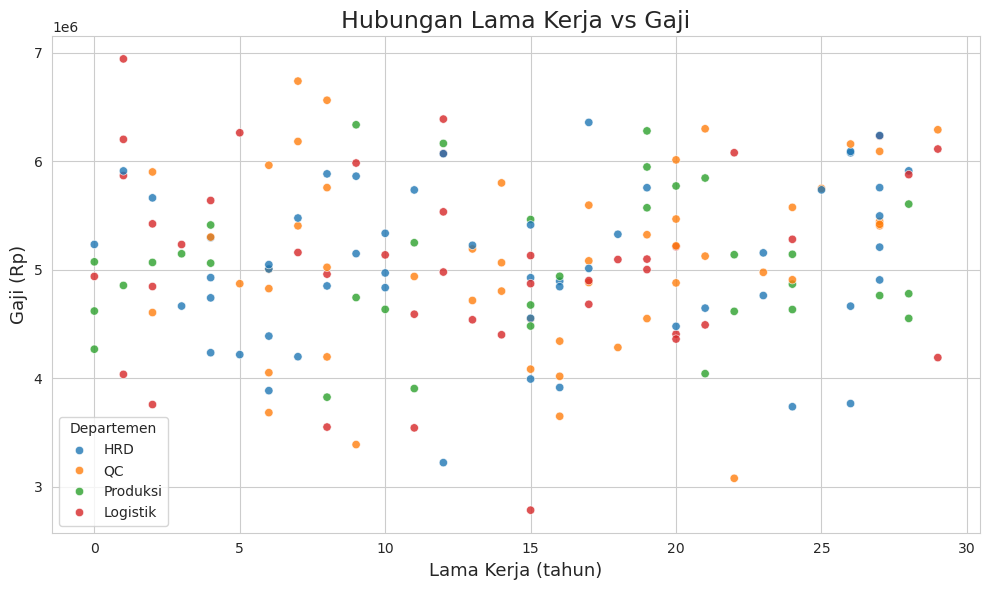

In [10]:
# Scatter Plot: Lama Kerja vs Gaji
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Lama_Kerja', y='Gaji', hue='Departemen', data=train, palette='tab10', alpha=0.8)
plt.title("Hubungan Lama Kerja vs Gaji", fontsize=17)
plt.xlabel("Lama Kerja (tahun)", fontsize=13)
plt.ylabel("Gaji (Rp)", fontsize=13)
plt.legend(title='Departemen')
plt.tight_layout()
plt.show()

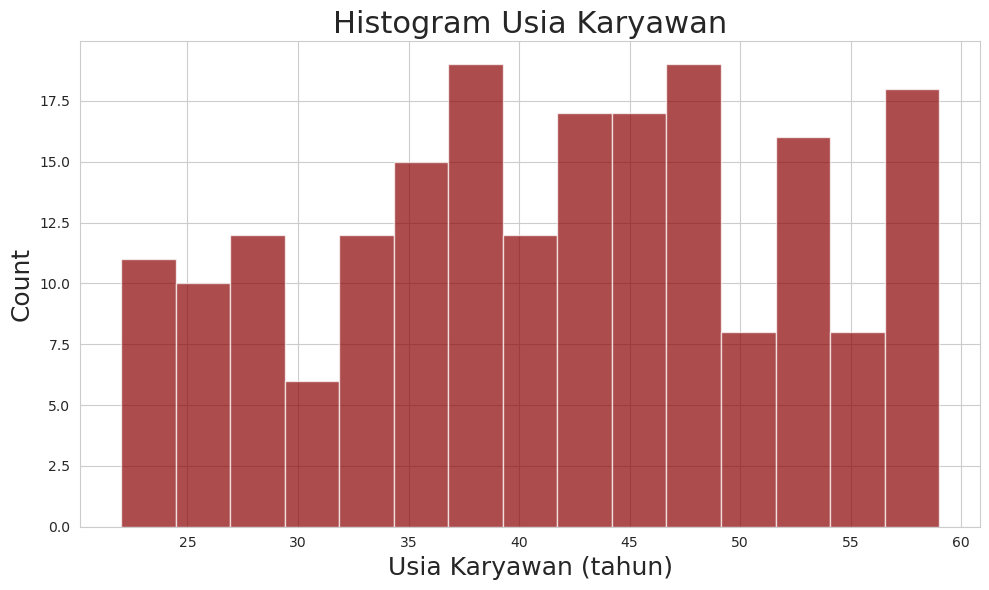

In [11]:
# Histogram Usia Karyawan
plt.figure(figsize=(10, 6))
train['Usia'].hist(bins=15, color='darkred', alpha=0.7, edgecolor='white')
plt.xlabel("Usia Karyawan (tahun)", fontsize=18)
plt.ylabel("Count", fontsize=18)
plt.title("Histogram Usia Karyawan", fontsize=22)
plt.tight_layout()
plt.show()

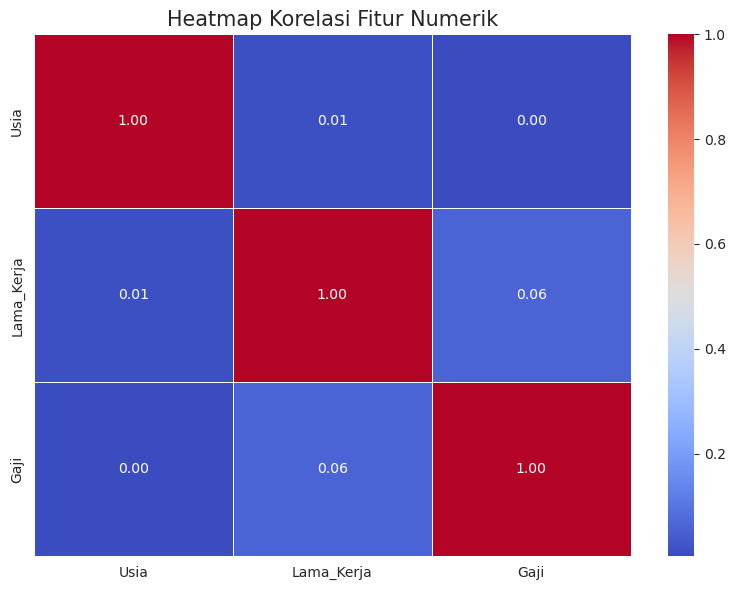

In [12]:
# Heatmap Korelasi Fitur Numerik
plt.figure(figsize=(8, 6))
corr = train[['Usia', 'Lama_Kerja', 'Gaji']].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5)
plt.title("Heatmap Korelasi Fitur Numerik", fontsize=15)
plt.tight_layout()
plt.show()

---
## 3. Feature Engineering

In [13]:
# Cek missing values
print("Missing values per kolom:")
print(train.isnull().sum())

Missing values per kolom:
ID                  0
Nama                0
Departemen         10
Gaji               10
Usia                0
Lama_Kerja          0
Status_Karyawan     0
dtype: int64


In [ ]:
# Imputasi Gaji yang hilang dengan median Gaji per Departemen
# Jika Departemen juga NaN, gunakan median global
dept_median_gaji = train.groupby('Departemen')['Gaji'].median()

def impute_gaji(row):
    if pd.isna(row['Gaji']):
        if not pd.isna(row['Departemen']):
            return dept_median_gaji.get(row['Departemen'], train['Gaji'].median())
        else:
            return train['Gaji'].median()
    return row['Gaji']

train['Gaji'] = train.apply(impute_gaji, axis=1)

# Imputasi Departemen yang hilang dengan modus (nilai terbanyak)
train['Departemen'] = train['Departemen'].fillna(train['Departemen'].mode()[0])

print("Missing values setelah imputasi:")
print(train.isnull().sum())

Missing values setelah imputasi:
ID                 0
Nama               0
Departemen         0
Gaji               0
Usia               0
Lama_Kerja         0
Status_Karyawan    0
dtype: int64


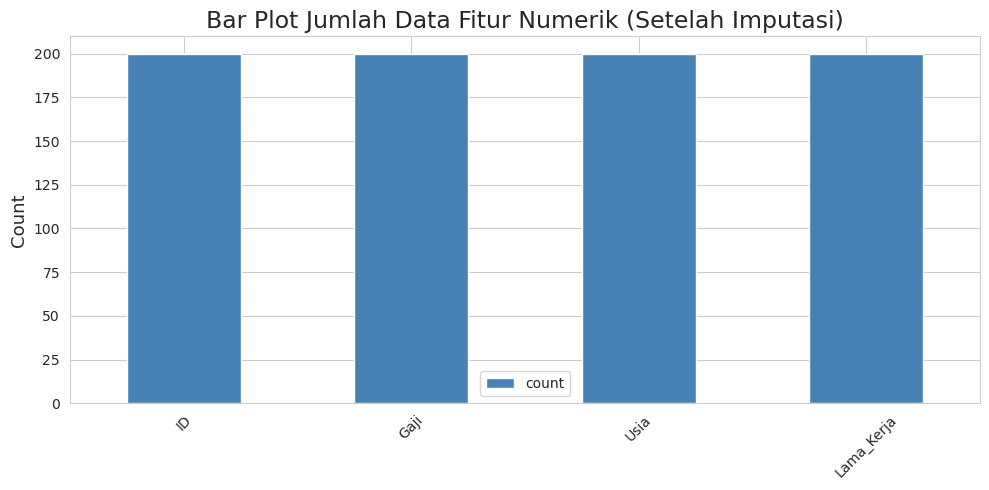

In [15]:
# Tampilkan jumlah data per fitur numerik setelah imputasi
d = train.describe()
dT = d.T
dT.plot.bar(y='count', figsize=(10, 5), color='steelblue')
plt.title("Bar Plot Jumlah Data Fitur Numerik (Setelah Imputasi)", fontsize=17)
plt.ylabel("Count", fontsize=13)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [16]:
# Drop kolom yang tidak relevan untuk modeling
train.drop(['ID', 'Nama'], axis=1, inplace=True)
train.head()

,Departemen,Gaji,Usia,Lama_Kerja,Status_Karyawan
0,HRD,5744870.0,53,9,Kontrak
1,HRD,5862014.0,39,9,Tetap
2,HRD,4894992.0,55,16,Tetap
3,QC,4606286.0,51,2,Kontrak
4,HRD,4199766.0,44,7,Kontrak


In [17]:
# Encode kolom kategorikal menggunakan LabelEncoder
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
categorical_cols = train.select_dtypes(include=['object']).columns.tolist()
print("Kolom kategorikal:", categorical_cols)

for col in categorical_cols:
    train[col] = le.fit_transform(train[col])

print("\nEncoding Departemen  : HRD=0, Logistik=1, Produksi=2, QC=3")
print("Encoding Status      : Kontrak=0, Tetap=1")
train.head()

Kolom kategorikal: ['Departemen', 'Status_Karyawan']

Encoding Departemen  : HRD=0, Logistik=1, Produksi=2, QC=3
Encoding Status      : Kontrak=0, Tetap=1


,Departemen,Gaji,Usia,Lama_Kerja,Status_Karyawan
0,0,5744870.0,53,9,0
1,0,5862014.0,39,9,1
2,0,4894992.0,55,16,1
3,3,4606286.0,51,2,0
4,0,4199766.0,44,7,0


In [18]:
# Normalisasi fitur numerik agar skala seragam (penting untuk KNN berbasis jarak)
from sklearn.preprocessing import StandardScaler

feature_cols = ['Usia', 'Lama_Kerja', 'Status_Karyawan', 'Departemen']
scaler = StandardScaler()
train[feature_cols] = scaler.fit_transform(train[feature_cols])
train.head()

,Departemen,Gaji,Usia,Lama_Kerja,Status_Karyawan
0,-1.159503,5744870.0,1.107666,-0.660652,-0.970437
1,-1.159503,5862014.0,-0.246094,-0.660652,1.030464
2,-1.159503,4894992.0,1.301060,0.187114,1.030464
3,1.352056,4606286.0,0.914272,-1.508418,-0.970437
4,-1.159503,4199766.0,0.237392,-0.902871,-0.970437


---
## 4. Training

In [19]:
from sklearn.model_selection import train_test_split

X = train.drop('Gaji', axis=1)
y = train['Gaji']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.30,
    random_state=42
)

In [20]:
print(f'Train shape: {X_train.shape}')
print(f'Test shape:  {X_test.shape}')

Train shape: (140, 4)
Test shape:  (60, 4)


### KNN — Model Default

In [21]:
from sklearn.neighbors import KNeighborsRegressor

reg1 = KNeighborsRegressor()
reg1.fit(X_train, y_train)

,n_neighbors,5
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [22]:
y_pred = reg1.predict(X_test)

---
## 5. Evaluation — Model Default

In [23]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

mae  = mean_absolute_error(y_test, y_pred)
mse  = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2   = r2_score(y_test, y_pred)

print(f'MAE  (Mean Absolute Error)  : Rp {mae:,.0f}')
print(f'MSE  (Mean Squared Error)   : {mse:,.0f}')
print(f'RMSE (Root Mean Sq. Error)  : Rp {rmse:,.0f}')
print(f'R²   (R-Squared)            : {r2:.4f}')

MAE  (Mean Absolute Error)  : Rp 584,260
MSE  (Mean Squared Error)   : 551,904,172,953
RMSE (Root Mean Sq. Error)  : Rp 742,903
R²   (R-Squared)            : -0.0662


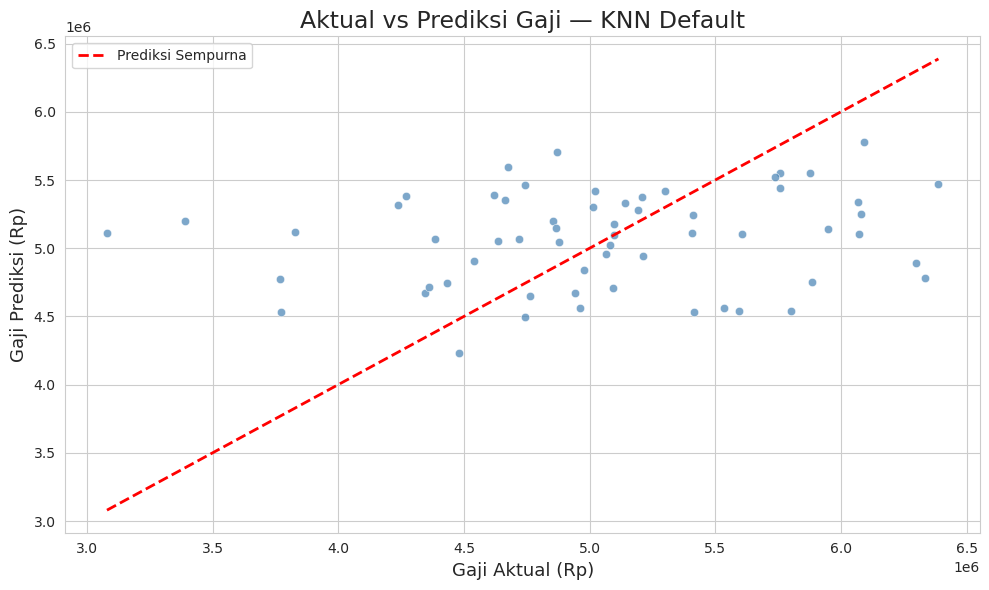

In [24]:
# Visualisasi Aktual vs Prediksi — Model Default
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred, alpha=0.7, color='steelblue', edgecolors='white', linewidth=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Prediksi Sempurna')
plt.xlabel("Gaji Aktual (Rp)", fontsize=13)
plt.ylabel("Gaji Prediksi (Rp)", fontsize=13)
plt.title("Aktual vs Prediksi Gaji — KNN Default", fontsize=17)
plt.legend()
plt.tight_layout()
plt.show()

### Jika kita mau mengubah parameter yang akan digunakan, bisa dilakukan seperti ini

In [25]:
reg2 = KNeighborsRegressor(n_neighbors=5, weights='distance', metric='euclidean')
reg2.fit(X_train, y_train)

y_pred1 = reg2.predict(X_test)

In [26]:
mae1  = mean_absolute_error(y_test, y_pred1)
rmse1 = np.sqrt(mean_squared_error(y_test, y_pred1))
r2_1  = r2_score(y_test, y_pred1)

print(f'Evaluasi Model KNN (custom params):')
print(f'MAE  : Rp {mae1:,.0f}')
print(f'RMSE : Rp {rmse1:,.0f}')
print(f'R²   : {r2_1:.4f}')

Evaluasi Model KNN (custom params):
MAE  : Rp 583,152
RMSE : Rp 766,356
R²   : -0.1346


### Jika ingin mencoba semua kombinasi parameter (GridSearchCV)

In [27]:
from sklearn.model_selection import GridSearchCV
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import make_scorer, mean_absolute_error, r2_score
import pandas as pd

# 1. Definisikan metrik-metrik scoring yang ingin digunakan
scoring = {
    'mae': make_scorer(mean_absolute_error, greater_is_better=False),
    'r2':  make_scorer(r2_score)
}

# 2. Parameter grid
param_grid = {
    'n_neighbors': [3, 5, 7, 9],
    'weights':     ['uniform', 'distance'],
    'metric':      ['euclidean', 'manhattan']
}

# 3. Buat model KNN Regressor
knn = KNeighborsRegressor()

# 4. GridSearch dengan semua metrik, pilih 'r2' sebagai metrik utama (refit)
grid_search = GridSearchCV(knn, param_grid, cv=5, scoring=scoring, refit='r2', verbose=1, n_jobs=-1)
grid_search.fit(X_train, y_train)

# 5. Hasil Cross-Validation (Training)
cv_results = pd.DataFrame(grid_search.cv_results_)
cv_metrics = cv_results[['params', 'mean_test_mae', 'mean_test_r2']].copy()
cv_metrics['mean_test_mae'] = cv_metrics['mean_test_mae'].abs()
print("\n=== Hasil Evaluasi Training (Cross-Validation) ===")
print(cv_metrics.sort_values(by='mean_test_r2', ascending=False).head(10).to_string(index=False))

Fitting 5 folds for each of 16 candidates, totalling 80 fits

=== Hasil Evaluasi Training (Cross-Validation) ===
                                                          params  mean_test_mae  mean_test_r2
 {'metric': 'euclidean', 'n_neighbors': 7, 'weights': 'uniform'}  647024.295408     -0.126257
 {'metric': 'euclidean', 'n_neighbors': 9, 'weights': 'uniform'}  643108.552778     -0.131477
 {'metric': 'manhattan', 'n_neighbors': 9, 'weights': 'uniform'}  656235.621429     -0.151416
 {'metric': 'euclidean', 'n_neighbors': 5, 'weights': 'uniform'}  645166.420714     -0.159829
 {'metric': 'manhattan', 'n_neighbors': 7, 'weights': 'uniform'}  650948.262245     -0.160644
{'metric': 'euclidean', 'n_neighbors': 9, 'weights': 'distance'}  654134.438291     -0.203633
{'metric': 'euclidean', 'n_neighbors': 7, 'weights': 'distance'}  659206.790555     -0.223488
{'metric': 'manhattan', 'n_neighbors': 9, 'weights': 'distance'}  673848.997540     -0.250070
 {'metric': 'manhattan', 'n_neighbors': 5

In [28]:
# Simpan hasil evaluasi ke file Excel
cv_metrics_sorted = cv_metrics.sort_values(by='mean_test_r2', ascending=False)
cv_metrics_sorted.to_excel("hasil_gridsearch_knn_karyawan.xlsx", index=False)

print("Hasil telah disimpan ke 'hasil_gridsearch_knn_karyawan.xlsx'")

Hasil telah disimpan ke 'hasil_gridsearch_knn_karyawan.xlsx'


In [29]:
best_model = grid_search.best_estimator_
print("\n=== Parameter Terbaik ===")
print(grid_search.best_params_)


=== Parameter Terbaik ===
{'metric': 'euclidean', 'n_neighbors': 7, 'weights': 'uniform'}


In [30]:
y_pred_best = best_model.predict(X_test)

mae_b  = mean_absolute_error(y_test, y_pred_best)
rmse_b = np.sqrt(mean_squared_error(y_test, y_pred_best))
r2_b   = r2_score(y_test, y_pred_best)

print("\n=== Evaluasi di Test Set (Model Terbaik) ===")
print(f"MAE  : Rp {mae_b:,.0f}")
print(f"RMSE : Rp {rmse_b:,.0f}")
print(f"R²   : {r2_b:.4f}")


=== Evaluasi di Test Set (Model Terbaik) ===
MAE  : Rp 607,899
RMSE : Rp 752,956
R²   : -0.0952


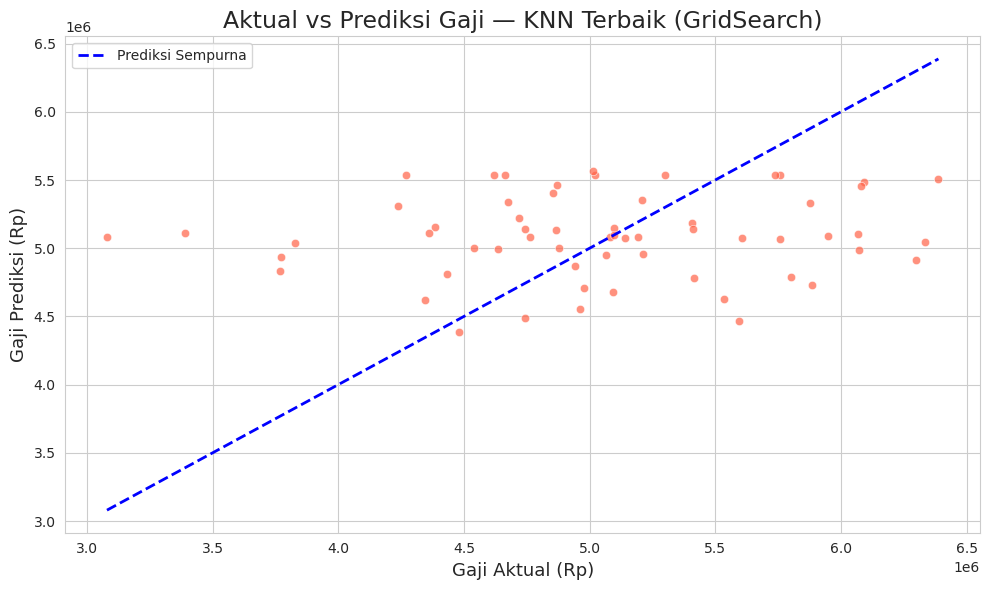

In [31]:
# Visualisasi Aktual vs Prediksi — Model Terbaik
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred_best, alpha=0.7, color='tomato', edgecolors='white', linewidth=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'b--', lw=2, label='Prediksi Sempurna')
plt.xlabel("Gaji Aktual (Rp)", fontsize=13)
plt.ylabel("Gaji Prediksi (Rp)", fontsize=13)
plt.title("Aktual vs Prediksi Gaji — KNN Terbaik (GridSearch)", fontsize=17)
plt.legend()
plt.tight_layout()
plt.show()

In [32]:
# Perbandingan ketiga model dalam satu tabel
comparison = pd.DataFrame({
    'Model': ['KNN Default', 'KNN Custom Params', 'KNN Best (GridSearch)'],
    'MAE (Rp)':  [f'{mae:,.0f}',  f'{mae1:,.0f}',  f'{mae_b:,.0f}'],
    'RMSE (Rp)': [f'{rmse:,.0f}', f'{rmse1:,.0f}', f'{rmse_b:,.0f}'],
    'R²':        [f'{r2:.4f}',    f'{r2_1:.4f}',   f'{r2_b:.4f}']
})
print(comparison.to_string(index=False))

                Model MAE (Rp) RMSE (Rp)      R²
          KNN Default  584,260   742,903 -0.0662
    KNN Custom Params  583,152   766,356 -0.1346
KNN Best (GridSearch)  607,899   752,956 -0.0952


---
## 6. Prediksi Data Baru

Contoh prediksi gaji untuk karyawan baru berdasarkan fitur-fitur yang tersedia.

In [33]:
# Tampilkan nama fitur yang digunakan model
print("Nama fitur yang digunakan model:")
print(list(X_train.columns))
print(f"Jumlah fitur: {X_train.shape[1]}")

Nama fitur yang digunakan model:
['Departemen', 'Usia', 'Lama_Kerja', 'Status_Karyawan']
Jumlah fitur: 4


In [34]:
import numpy as np

# Encoding referensi:
#   Departemen      : HRD=0, Logistik=1, Produksi=2, QC=3
#   Status_Karyawan : Kontrak=0, Tetap=1

# Contoh karyawan baru:
# Usia=35, Lama_Kerja=5, Status=Tetap(1), Departemen=HRD(0)
data_baru_raw = pd.DataFrame({
    'Usia':            [35],
    'Lama_Kerja':      [5],
    'Status_Karyawan': [1],   # Tetap
    'Departemen':      [0]    # HRD
})

# Normalisasi menggunakan scaler yang sudah di-fit sebelumnya
data_baru_scaled = scaler.transform(data_baru_raw)

# Prediksi menggunakan model terbaik
prediksi_gaji = best_model.predict(data_baru_scaled)

print("Data Karyawan Baru:")
print("  Usia          : 35 tahun")
print("  Lama Kerja    : 5 tahun")
print("  Status        : Tetap")
print("  Departemen    : HRD")
print()
print(f"Prediksi Gaji   : Rp {prediksi_gaji[0]:,.0f}")

Data Karyawan Baru:
  Usia          : 35 tahun
  Lama Kerja    : 5 tahun
  Status        : Tetap
  Departemen    : HRD

Prediksi Gaji   : Rp 5,238,167


/home/hisyam/Downloads/enter/lib/python3.13/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but KNeighborsRegressor was fitted with feature names
  warnings.warn(


<h1>Jelaskan peran feature engineering dalam pemodelan Machine Learning. Jelaskan contohnya dari
studi kasus masing-masing.</h1>


Feature engineering adalah proses mengolah dan mempersiapkan data mentah menjadi representasi yang lebih baik agar model machine learning dapat belajar dengan lebih efektif. Kualitas fitur sering kali lebih berpengaruh terhadap performa model dibandingkan pemilihan algoritma itu sendiri.
Secara umum, perannya mencakup tiga hal utama:

Membersihkan data dimana menangani nilai yang hilang atau tidak konsisten agar model tidak error
Mengubah format data dengan cara mengkonversi tipe data yang tidak bisa dibaca model (misalnya teks/kategori = angka)
Menyeragamkan skala dan memastikan semua fitur berada pada rentang yang sebanding agar tidak ada fitur yang mendominasi secara tidak adil

<h2>Contoh </h2>
1. Imputasi Missing Values

Dataset memiliki 10 nilai kosong pada kolom Gaji dan 10 pada Departemen. Daripada membuang baris tersebut, dilakukan imputasi:


In [38]:
train['Gaji'] = train.apply(impute_gaji, axis=1)

# Imputasi Departemen yang hilang dengan modus (nilai terbanyak)
train['Departemen'] = train['Departemen'].fillna(train['Departemen'].mode()[0])

2. Label Encoding (Kategorikal → Numerik)

Kolom Status_Karyawan dan Departemen berisi teks. Model matematika seperti KNN hanya memahami angka, sehingga perlu dikonversi:

In [39]:
le = LabelEncoder()
categorical_cols = train.select_dtypes(include=['object']).columns.tolist()
print("Kolom kategorikal:", categorical_cols)

for col in categorical_cols:
    train[col] = le.fit_transform(train[col])


Kolom kategorikal: []


<h1>Apa itu confusion metrik dan metrik evaluasi jika dilihat dari studi kasus masing-masing,
Jelaskan?</h1>

<h2>Metrik Evaluasi yang Digunakan </h2>

Karena targetnya adalah angka (Gaji), metrik yang dipakai mengukur seberapa jauh prediksi meleset dari nilai aslinya:
MAE  (Mean Absolute Error)
Rata-rata selisih absolut antara prediksi dan nilai aktual.

In [ ]:
MAE = rata-rata dari |Gaji_aktual - Gaji_prediksi|

Mudah diinterpretasi — misalnya MAE = Rp 584.000 artinya prediksi meleset rata-rata Rp 584.000 dari gaji sesungguhny

<h2>Confusion Matrix yang digunakan</h2>

notebook yang dibuat tidak menggunakan confusion matrix, karena task-nya adalah regresi (memprediksi nilai kontinu berupa Gaji dalam Rupiah), bukan klasifikasi.
Confusion matrix hanya digunakan untuk klasifikasi, seperti pada contoh ipynb yang memprediksi lulus/tidak lulus (0 atau 1).

<h2>Perbedaan antara kedua matrix</h2>

Confusion matrix adalah alat evaluasi khusus untuk model klasifikasi, yaitu model yang memprediksi kelas atau kategori (contoh: lulus/tidak lulus, spam/bukan spam). Matriks ini menampilkan berapa banyak prediksi yang benar dan salah untuk setiap kelas, dari situ kemudian diturunkan metrik seperti Accuracy, Precision, Recall, dan F1-Score. Pada ipynb atau tugas sebelumnya , confusion matrix digunakan karena model memprediksi apakah siswa lulus (1) atau tidak lulus (0).



Metrik evaluasi regresi seperti MAE, RMSE, dan R² digunakan ketika model memprediksi nilai kontinu (angka), bukan kategori. Pada notebook KNN_Karyawan_Regression.ipynb yang dibuat, metrik inilah yang dipakai karena target prediksinya adalah Gaji dalam Rupiah — sebuah nilai numerik yang tidak bisa dievaluasi dengan confusion matrix. MAE dan RMSE mengukur seberapa jauh prediksi meleset dari nilai aslinya, sementara R² mengukur seberapa baik model secara keseluruhan menjelaskan pola dalam data.